# Knowledge Graph Builder - ATC Entities

Este notebook construye un grafo de conocimiento a partir de las entidades y relaciones extraídas por kex.ipynb.

## Flujo:
1. Cargar JSON de un modelo específico
2. Consolidar entidades (deduplicación exacta)
3. Construir grafo con NetworkX
4. Análisis estático (centralidad, comunidades)
5. Visualización del grafo

In [1]:
import json
import os
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict, Counter
import numpy as np
from community import community_louvain
import seaborn as sns

## Cargar datos de un modelo específico

In [2]:
def load_kex_output(output_dir, model_name="llama3"):
    """
    Carga todos los JSON de un modelo específico desde kex_output
    """
    base_path = Path(output_dir)
    model_folder = None
    
    # Buscar carpeta del modelo
    for folder in base_path.iterdir():
        if folder.is_dir() and model_name in folder.name:
            model_folder = folder
            break
    
    if not model_folder:
        raise ValueError(f"No se encontró carpeta para el modelo: {model_name}")
    
    print(f"Cargando datos desde: {model_folder}")
    
    all_data = []
    
    for json_file in sorted(model_folder.glob("pagina_*.json")):
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                data['source_file'] = json_file.name
                data['page_number'] = int(json_file.stem.split('_')[1])
                all_data.append(data)
        except Exception as e:
            print(f"Error cargando {json_file}: {e}")
    
    print(f"Cargadas {len(all_data)} páginas")
    return all_data

In [3]:
# Cargar datos del modelo llama3
data = load_kex_output("output/2_kex_output" ,"mistral:7b")


Cargando datos desde: output/2_kex_output/ICAO Standard Phraseology(mistral:7b) 
Cargadas 20 páginas


## Consolidar entidades (deduplicación exacta)

In [4]:
def consolidate_entities(all_data):
    """
    Consolida entidades usando matching exacto (text.lower().strip())
    """
    entity_map = {}  # normalized_text -> entity_info
    entity_sources = defaultdict(list)  # normalized_text -> list of (page, file)
    
    for page_data in all_data:
        page_num = page_data['page_number']
        source_file = page_data['source_file']
        
        ner_data = page_data.get('ner', {})
        if not isinstance(ner_data, dict) or 'entities' not in ner_data:
            continue
            
        for entity in ner_data['entities']:
            if not isinstance(entity, dict) or 'text' not in entity:
                continue
                
            text = entity['text']
            normalized = text.lower().strip()
            
            # Si no existe, guardar la primera aparición
            if normalized not in entity_map:
                entity_map[normalized] = {
                    'text': text,
                    'label': entity.get('label', 'Unknown'),
                    'context': entity.get('context', ''),
                    'first_seen_page': page_num,
                    'frequency': 1
                }
            else:
                # Actualizar frecuencia
                entity_map[normalized]['frequency'] += 1
            
            # Registrar fuente
            entity_sources[normalized].append((page_num, source_file))
    
    print(f"Entidades únicas consolidadas: {len(entity_map)}")
    return entity_map, entity_sources

In [5]:
# Consolidar entidades
entity_map, entity_sources = consolidate_entities(data)

# Mostrar algunas estadísticas
print("\nTop 10 entidades más frecuentes:")
for normalized, info in sorted(entity_map.items(), key=lambda x: x[1]['frequency'], reverse=True)[:10]:
    print(f"{info['text']} ({info['label']}): {info['frequency']} veces")

Entidades únicas consolidadas: 209

Top 10 entidades más frecuentes:
ALL CLEAR (Clearence): 19 veces
AGC (Air Ground Communication): 19 veces
safety initiative (Program): 19 veces
Big Jet 345 (Aircraft): 15 veces
ICAO Phraseology Reference Guide (Document): 13 veces
runway 27 (Airfield Facility): 5 veces
RTF (Communication Protocol): 4 veces
Metro Tower (ATC Facility): 4 veces
Commercial Air Transport (CAT) pilots (Pilots): 2 veces
IFR (Instrument Flight Rules): 2 veces


## Construir grafo de conocimiento

In [6]:
def build_knowledge_graph(all_data, entity_map):
    """
    Construye el grafo de conocimiento usando NetworkX
    """
    G = nx.DiGraph()  # Grafo dirigido
    
    # Agregar nodos (entidades)
    for normalized, entity_info in entity_map.items():
        G.add_node(
            normalized,
            text=entity_info['text'],
            label=entity_info['label'],
            context=entity_info['context'],
            frequency=entity_info['frequency'],
            first_seen_page=entity_info['first_seen_page']
        )
    
    # Agregar aristas (relaciones)
    relationship_count = 0
    missing_entities = set()
    
    for page_data in all_data:
        ner_data = page_data.get('ner', {})
        if not isinstance(ner_data, dict) or 'relationships' not in ner_data:
            continue
            
        for rel in ner_data['relationships']:
            if not isinstance(rel, dict):
                continue
                
            subject = rel.get('subject', '')
            predicate = rel.get('predicate', '')
            obj = rel.get('object', '')
            
            if not all([subject, predicate, obj]):
                continue
            
            # Normalizar para buscar en entity_map
            subj_norm = subject.lower().strip()

            if isinstance(obj, str):
                obj_norm = obj.lower().strip()
            else:
                obj = ",".join(obj)
                obj_norm = obj.lower().strip()
            
            # Verificar que ambas entidades existan
            if subj_norm in entity_map and obj_norm in entity_map:
                G.add_edge(
                    subj_norm, 
                    obj_norm, 
                    predicate=predicate,
                    source_page=page_data['page_number'],
                    source_file=page_data['source_file']
                )
                relationship_count += 1
            else:
                # Registrar entidades faltantes
                if subj_norm not in entity_map:
                    missing_entities.add(subject)
                if obj_norm not in entity_map:
                    missing_entities.add(obj)
    
    print(f"Grafo construido:")
    print(f"- Nodos (entidades): {G.number_of_nodes()}")
    print(f"- Aristas (relaciones): {G.number_of_edges()}")
    print(f"- Relaciones procesadas: {relationship_count}")
    
    if missing_entities:
        print(f"\nEntidades mencionadas en relaciones pero no encontradas: {len(missing_entities)} ({len(missing_entities)*100/len(entity_map):.2f} %)")
        for entity in list(missing_entities)[:5]:  # Mostrar primeras 5
            print(f"  - {entity}")
    
    return G, missing_entities

In [8]:
# Construir el grafo
G, missing_entities = build_knowledge_graph(data, entity_map)

Grafo construido:
- Nodos (entidades): 209
- Aristas (relaciones): 82
- Relaciones procesadas: 95

Entidades mencionadas en relaciones pero no encontradas: 125 (59.81 %)
  - 110, 210 and 310
  - loss of communications procedures
  - both level busts and runway incursions in Europe
  - Clearence
  - cockpit workload to be high


In [7]:
for model_name in ["deepseek-r1:7b", "gemma2:9b", "llama3.1", "mistral:7b", "qwen2.5:7b", "qwen2.5-coder:7b", "gpt-oss:20b", "deepseek-r1:14b", "deepseek-v2:16b", "mistral:7b-instruct", "qwen2.5:14b"]:
    print( f"\n=={model_name.upper()}==\n")
    data = load_kex_output("output/3_kex_output" ,model_name)
    entity_map, entity_sources = consolidate_entities(data)
    G, missing_entities = build_knowledge_graph(data, entity_map)
    print("\n----------------------------------------\n")


==DEEPSEEK-R1:7B==

Cargando datos desde: output/3_kex_output/ICAO Standard Phraseology(deepseek-r1:7b) 
Cargadas 20 páginas
Entidades únicas consolidadas: 112
Grafo construido:
- Nodos (entidades): 112
- Aristas (relaciones): 28
- Relaciones procesadas: 44

Entidades mencionadas en relaciones pero no encontradas: 37 (33.04 %)
  - holding point C1
  - 3000 feet
  - ATC - Big Jet 345, Metro Ground, taxi to holding point A1, hold short of Runway 18
  - Take-off clearance
  - Conditional Line Up Clearance

----------------------------------------


==GEMMA2:9B==

Cargando datos desde: output/3_kex_output/ICAO Standard Phraseology(gemma2:9b) 
Cargadas 20 páginas
Entidades únicas consolidadas: 151
Grafo construido:
- Nodos (entidades): 151
- Aristas (relaciones): 50
- Relaciones procesadas: 56

Entidades mencionadas en relaciones pero no encontradas: 67 (44.37 %)
  - phraseology for amendments to departure clearances
  - in the TMA
  - taxi
  - After the aircraft has commenced the take-off

## Análisis estático del grafo

In [12]:
def analyze_graph(G):
    """
    Realiza análisis estático del grafo
    """
    stats = {}
    
    # Estadísticas básicas
    stats['nodes'] = G.number_of_nodes()
    stats['edges'] = G.number_of_edges()
    stats['density'] = nx.density(G)
    stats['is_connected'] = nx.is_weakly_connected(G)
    
    # Centralidades
    if G.number_of_nodes() > 0:
        stats['degree_centrality'] = nx.degree_centrality(G)
        stats['betweenness_centrality'] = nx.betweenness_centrality(G)
        stats['closeness_centrality'] = nx.closeness_centrality(G)
        stats['pagerank'] = nx.pagerank(G)
    
    # Componentes conectados
    weak_components = list(nx.weakly_connected_components(G))
    stats['weak_components'] = len(weak_components)
    stats['largest_component_size'] = len(max(weak_components)) if weak_components else 0
    
    return stats

In [13]:
# Analizar el grafo
stats = analyze_graph(G)

print("=== ESTADÍSTICAS DEL GRAFO ===")
print(f"Nodos: {stats['nodes']}")
print(f"Aristas: {stats['edges']}")
print(f"Densidad: {stats['density']:.4f}")
print(f"Conectado: {stats['is_connected']}")
print(f"Componentes débiles: {stats['weak_components']}")
print(f"Componente más grande: {stats['largest_component_size']} nodos")

=== ESTADÍSTICAS DEL GRAFO ===
Nodos: 135
Aristas: 50
Densidad: 0.0028
Conectado: False
Componentes débiles: 88
Componente más grande: 3 nodos


### Top entidades por centralidad

In [14]:
def show_top_entities(stats, entity_map, top_n=10):
    """
    Muestra las entidades top por diferentes métricas de centralidad
    """
    metrics = ['degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'pagerank']
    
    for metric in metrics:
        if metric in stats:
            print(f"\n=== Top {top_n} por {metric.replace('_', ' ').title()} ===")
            
            # Ordenar por la métrica
            sorted_entities = sorted(
                stats[metric].items(), 
                key=lambda x: x[1], 
                reverse=True
            )[:top_n]
            
            for i, (entity_norm, score) in enumerate(sorted_entities, 1):
                entity_info = entity_map[entity_norm]
                print(f"{i:2d}. {entity_info['text']} ({entity_info['label']}) - {score:.4f}")

In [14]:
# Mostrar top entidades
show_top_entities(stats, entity_map)


=== Top 10 por Degree Centrality ===
 1. Big Jet 345 (Aircraft) - 0.2677
 2. ATC (Organization) - 0.0236
 3. Cancel take-off (ATC Instruction) - 0.0157
 4. Metro Control (ATC Facility) - 0.0157
 5. vehicle on the runway (Runway Hazard) - 0.0079
 6. runway 27 (Aerodrome Feature) - 0.0079
 7. Metro Radar (ATC Facility) - 0.0079
 8. 2300 feet (Altitude) - 0.0079
 9. 6000 feet (Altitude) - 0.0079
10. BONNY (Fix/Position) - 0.0079

=== Top 10 por Betweenness Centrality ===
 1. Big Jet 345 (Aircraft) - 0.0060
 2. ATC (Organization) - 0.0021
 3. Commercial Air Transport (CAT) (Aircraft Type) - 0.0000
 4. European Airspace (Airspace) - 0.0000
 5. Instrument Flight Rules (IFR) (Flight Rules) - 0.0000
 6. hold position (ATC Instruction) - 0.0000
 7. Cancel take-off (ATC Instruction) - 0.0000
 8. vehicle on the runway (Runway Hazard) - 0.0000
 9. stop immediately (ATC Instruction) - 0.0000
10. READ-BACK (ATC Procedure) - 0.0000

=== Top 10 por Closeness Centrality ===
 1. Big Jet 345 (Aircraft) 

### Distribución de tipos de entidades

In [15]:
def analyze_entity_types(entity_map):
    """
    Analiza la distribución de tipos de entidades
    """
    label_counts = Counter()
    label_freq = defaultdict(list)
    
    for entity_info in entity_map.values():
        label = entity_info['label']
        label_counts[label] += 1
        label_freq[label].append(entity_info['frequency'])
    
    # Estadísticas por tipo
    print("=== DISTRIBUCIÓN DE TIPOS DE ENTIDADES ===")
    for label, count in label_counts.most_common():
        avg_freq = np.mean(label_freq[label])
        print(f"{label}: {count} entidades (freq promedio: {avg_freq:.1f})")
    
    return label_counts

In [16]:
# Analizar tipos de entidades
label_counts = analyze_entity_types(entity_map)

=== DISTRIBUCIÓN DE TIPOS DE ENTIDADES ===
Altitude: 13 entidades (freq promedio: 1.2)
Instruction Type: 11 entidades (freq promedio: 1.0)
Document: 8 entidades (freq promedio: 1.0)
Heading: 7 entidades (freq promedio: 1.4)
Fix/Position: 7 entidades (freq promedio: 1.4)
ATC Procedure: 6 entidades (freq promedio: 1.0)
Runway: 5 entidades (freq promedio: 2.6)
Frequency: 5 entidades (freq promedio: 1.2)
Information: 4 entidades (freq promedio: 1.0)
Organization: 4 entidades (freq promedio: 1.0)
Action: 3 entidades (freq promedio: 1.3)
Aircraft: 3 entidades (freq promedio: 5.7)
Facility: 3 entidades (freq promedio: 2.7)
Aircraft Type: 3 entidades (freq promedio: 1.0)
Airspace: 2 entidades (freq promedio: 1.5)
Communication Method: 2 entidades (freq promedio: 3.5)
Safety Incident: 2 entidades (freq promedio: 1.0)
Departure Runway: 2 entidades (freq promedio: 1.5)
System Action: 2 entidades (freq promedio: 1.0)
Relative Position: 2 entidades (freq promedio: 1.0)
Distance: 2 entidades (freq p

### Tipos de relaciones (predicados)

In [17]:
def analyze_relationships(G):
    """
    Analiza los tipos de relaciones en el grafo
    """
    predicate_counts = Counter()
    
    for u, v, data in G.edges(data=True):
        predicate = data.get('predicate', 'Unknown')
        predicate_counts[predicate] += 1
    
    print("=== TIPOS DE RELACIONES ===")
    for predicate, count in predicate_counts.most_common():
        print(f"{predicate}: {count} relaciones")
    
    return predicate_counts

In [18]:
# Analizar relaciones
predicate_counts = analyze_relationships(G)

=== TIPOS DE RELACIONES ===
received instruction to: 3 relaciones
passing: 2 relaciones
climb to: 2 relaciones
fly direct: 2 relaciones
flies in: 1 relaciones
uses: 1 relaciones
provides guidance on: 1 relaciones
receives: 1 relaciones
Lines up: 1 relaciones
Climbs to: 1 relaciones
fly: 1 relaciones
contact: 1 relaciones
cleared to: 1 relaciones
turn right: 1 relaciones
descend to: 1 relaciones
speed: 1 relaciones
leave: 1 relaciones
cleared to land: 1 relaciones
receive: 1 relaciones
execute: 1 relaciones
communicated via: 1 relaciones
declared: 1 relaciones
was on: 1 relaciones
was at: 1 relaciones
must cross: 1 relaciones
must taxi to: 1 relaciones
must hold short of: 1 relaciones
request taxi: 1 relaciones
request: 1 relaciones
squawk: 1 relaciones
slot time: 1 relaciones
Holds at: 1 relaciones
must contact: 1 relaciones
contacts: 1 relaciones
contains: 1 relaciones
able to resume: 1 relaciones
is used for: 1 relaciones
Used for: 1 relaciones
issues: 1 relaciones
Issues: 1 relacion

### Detección de comunidades

In [19]:
def detect_communities(G):
    """
    Detecta comunidades usando el algoritmo de Louvain
    """
    # Convertir a grafo no dirigido para detección de comunidades
    G_undirected = G.to_undirected()
    
    # Detectar comunidades
    communities = community_louvain.best_partition(G_undirected)
    
    # Estadísticas de comunidades
    community_sizes = Counter(communities.values())
    
    print(f"=== COMUNIDADES DETECTADAS ===")
    print(f"Número de comunidades: {len(community_sizes)}")
    
    for comm_id, size in community_sizes.most_common():
        print(f"Comunidad {comm_id}: {size} nodos")
    
    return communities, community_sizes

In [20]:
# Detectar comunidades
communities, community_sizes = detect_communities(G)

=== COMUNIDADES DETECTADAS ===
Número de comunidades: 89
Comunidad 4: 36 nodos
Comunidad 2: 5 nodos
Comunidad 42: 5 nodos
Comunidad 0: 3 nodos
Comunidad 28: 2 nodos
Comunidad 1: 1 nodos
Comunidad 5: 1 nodos
Comunidad 6: 1 nodos
Comunidad 7: 1 nodos
Comunidad 8: 1 nodos
Comunidad 9: 1 nodos
Comunidad 10: 1 nodos
Comunidad 11: 1 nodos
Comunidad 12: 1 nodos
Comunidad 13: 1 nodos
Comunidad 14: 1 nodos
Comunidad 15: 1 nodos
Comunidad 16: 1 nodos
Comunidad 17: 1 nodos
Comunidad 18: 1 nodos
Comunidad 19: 1 nodos
Comunidad 20: 1 nodos
Comunidad 21: 1 nodos
Comunidad 22: 1 nodos
Comunidad 23: 1 nodos
Comunidad 24: 1 nodos
Comunidad 25: 1 nodos
Comunidad 26: 1 nodos
Comunidad 27: 1 nodos
Comunidad 29: 1 nodos
Comunidad 30: 1 nodos
Comunidad 31: 1 nodos
Comunidad 32: 1 nodos
Comunidad 33: 1 nodos
Comunidad 34: 1 nodos
Comunidad 35: 1 nodos
Comunidad 36: 1 nodos
Comunidad 37: 1 nodos
Comunidad 38: 1 nodos
Comunidad 39: 1 nodos
Comunidad 40: 1 nodos
Comunidad 41: 1 nodos
Comunidad 43: 1 nodos
Comun

## Visualización del grafo

In [21]:
def visualize_graph(G, entity_map, communities=None, layout='spring', figsize=(15, 10)):
    """
    Visualiza el grafo con matplotlib
    """
    plt.figure(figsize=figsize)
    
    # Layout
    if layout == 'spring':
        pos = nx.spring_layout(G, k=3, iterations=50)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    else:
        pos = nx.random_layout(G)
    
    # Colores por tipo de entidad
    label_colors = {}
    unique_labels = list(set(entity_map[node]['label'] for node in G.nodes()))
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        label_colors[label] = colors[i]
    
    node_colors = [label_colors[entity_map[node]['label']] for node in G.nodes()]
    
    # Tamaño de nodos por centralidad de grado
    degrees = dict(G.degree())
    node_sizes = [degrees[node] * 100 + 200 for node in G.nodes()]
    
    # Dibujar grafo
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.7)
    nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=20)
    
    # Etiquetas solo para nodos importantes
    important_nodes = [node for node, degree in degrees.items() if degree > np.percentile(list(degrees.values()), 75)]
    labels = {node: entity_map[node]['text'] for node in important_nodes}
    nx.draw_networkx_labels(G, pos, labels, font_size=8)
    
    # Leyenda
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                               markerfacecolor=label_colors[label], markersize=10, label=label)
                      for label in unique_labels]
    plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.15, 1))
    
    plt.title(f"Grafo de Conocimiento ATC\n{G.number_of_nodes()} nodos, {G.number_of_edges()} aristas")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    return pos

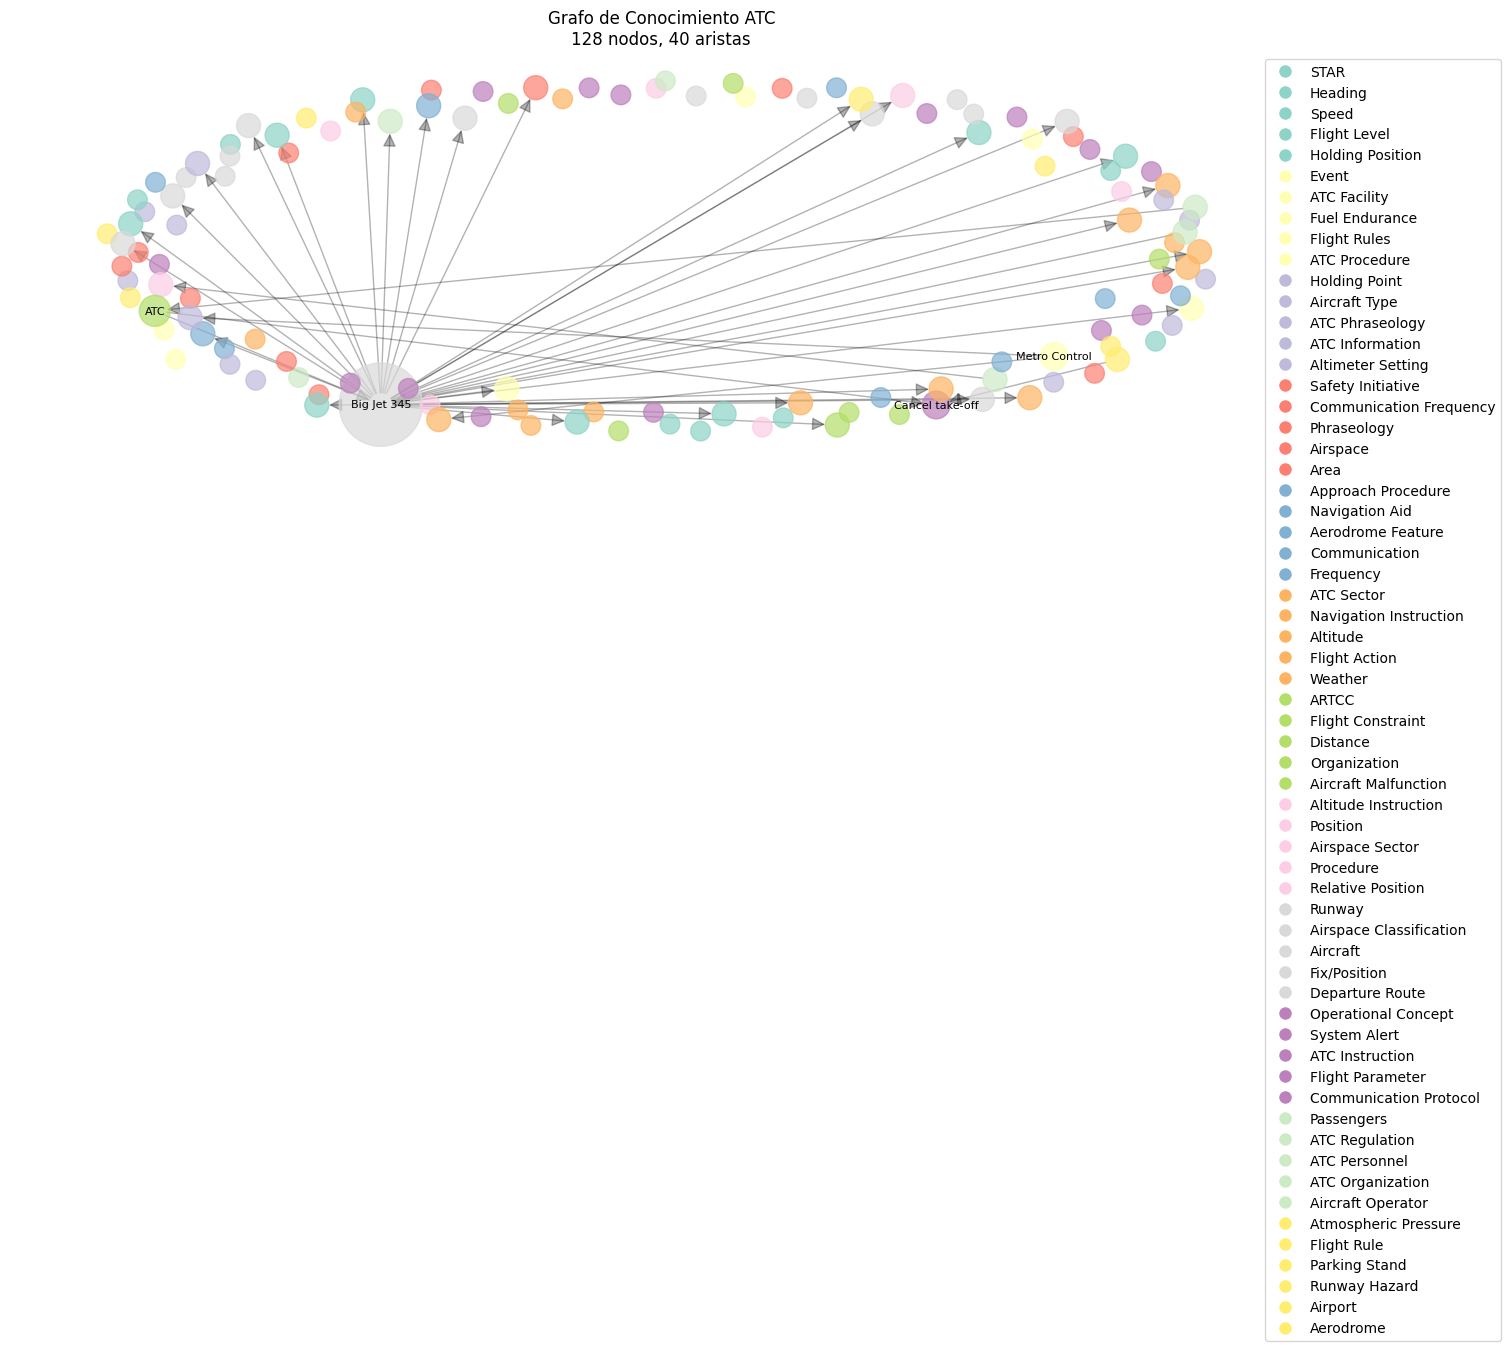

In [22]:
# Visualizar el grafo
pos = visualize_graph(G, entity_map, communities)

## Exportar grafo

In [22]:
def export_graph(G, entity_map, output_dir="graph_output", model_name="llama3"):
    """
    Exporta el grafo en múltiples formatos
    """
    # Crear directorio de salida
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)
    
    base_filename = f"atc_kg_{model_name}"
    
    # 1. Exportar como GraphML (para NetworkX)
    graphml_file = output_path / f"{base_filename}.graphml"
    nx.write_graphml(G, graphml_file)
    print(f"Guardado GraphML: {graphml_file}")
    
    # 2. Exportar como JSON (custom format)
    json_data = {
        'metadata': {
            'model': model_name,
            'nodes': G.number_of_nodes(),
            'edges': G.number_of_edges(),
            'created_at': pd.Timestamp.now().isoformat()
        },
        'nodes': [],
        'edges': []
    }
    
    # Agregar nodos
    for node in G.nodes():
        node_data = G.nodes[node]
        json_data['nodes'].append({
            'id': node,
            'text': node_data['text'],
            'label': node_data['label'],
            'context': node_data['context'],
            'frequency': node_data['frequency'],
            'first_seen_page': node_data['first_seen_page']
        })
    
    # Agregar aristas
    for u, v, data in G.edges(data=True):
        json_data['edges'].append({
            'source': u,
            'target': v,
            'predicate': data['predicate'],
            'source_page': data['source_page'],
            'source_file': data['source_file']
        })
    
    json_file = output_path / f"{base_filename}.json"
    with open(json_file, 'w', encoding='utf-8') as f:
        json.dump(json_data, f, indent=2, ensure_ascii=False)
    print(f"Guardado JSON: {json_file}")
    
    # 3. Exportar nodos como CSV
    nodes_df = pd.DataFrame([{
        'id': node,
        'text': G.nodes[node]['text'],
        'label': G.nodes[node]['label'],
        'context': G.nodes[node]['context'],
        'frequency': G.nodes[node]['frequency'],
        'first_seen_page': G.nodes[node]['first_seen_page']
    } for node in G.nodes()])
    
    nodes_csv = output_path / f"{base_filename}_nodes.csv"
    nodes_df.to_csv(nodes_csv, index=False, encoding='utf-8')
    print(f"Guardado CSV nodos: {nodes_csv}")
    
    # 4. Exportar aristas como CSV
    edges_df = pd.DataFrame([{
        'source': u,
        'target': v,
        'predicate': data['predicate'],
        'source_page': data['source_page'],
        'source_file': data['source_file']
    } for u, v, data in G.edges(data=True)])
    
    edges_csv = output_path / f"{base_filename}_edges.csv"
    edges_df.to_csv(edges_csv, index=False, encoding='utf-8')
    print(f"Guardado CSV aristas: {edges_csv}")
    
    return output_path

In [23]:
# Exportar el grafo
export_path = export_graph(G, entity_map, model_name="gemma2:9b")

Guardado GraphML: graph_output/atc_kg_gemma2:9b.graphml
Guardado JSON: graph_output/atc_kg_gemma2:9b.json
Guardado CSV nodos: graph_output/atc_kg_gemma2:9b_nodes.csv
Guardado CSV aristas: graph_output/atc_kg_gemma2:9b_edges.csv
